<a href="https://colab.research.google.com/github/FrancinaDharshini/DAA-Lab/blob/main/1C.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

  RUNNING EXPERIMENTS …

  Dataset: 10,000
  Algorithm               Avg      Max      Min         ms
  ──────────────────────────────────────────────────
  Interpolation          7.65       16        1       1.58
  Binary                12.63       14        2       1.39
  Linear              6394.57    10000        4     270.81

  Dataset: 50,000
  Algorithm               Avg      Max      Min         ms
  ──────────────────────────────────────────────────
  Interpolation          7.82       16        3       1.69
  Binary                15.03       16        3       1.85
  Linear             33060.19    50000       35    1452.65

  Dataset: 100,000
  Algorithm               Avg      Max      Min         ms
  ──────────────────────────────────────────────────
  Interpolation          8.03       16        3       1.78
  Binary                16.07       17        9       2.05
  Linear             64031.03   100000      227    2866.39



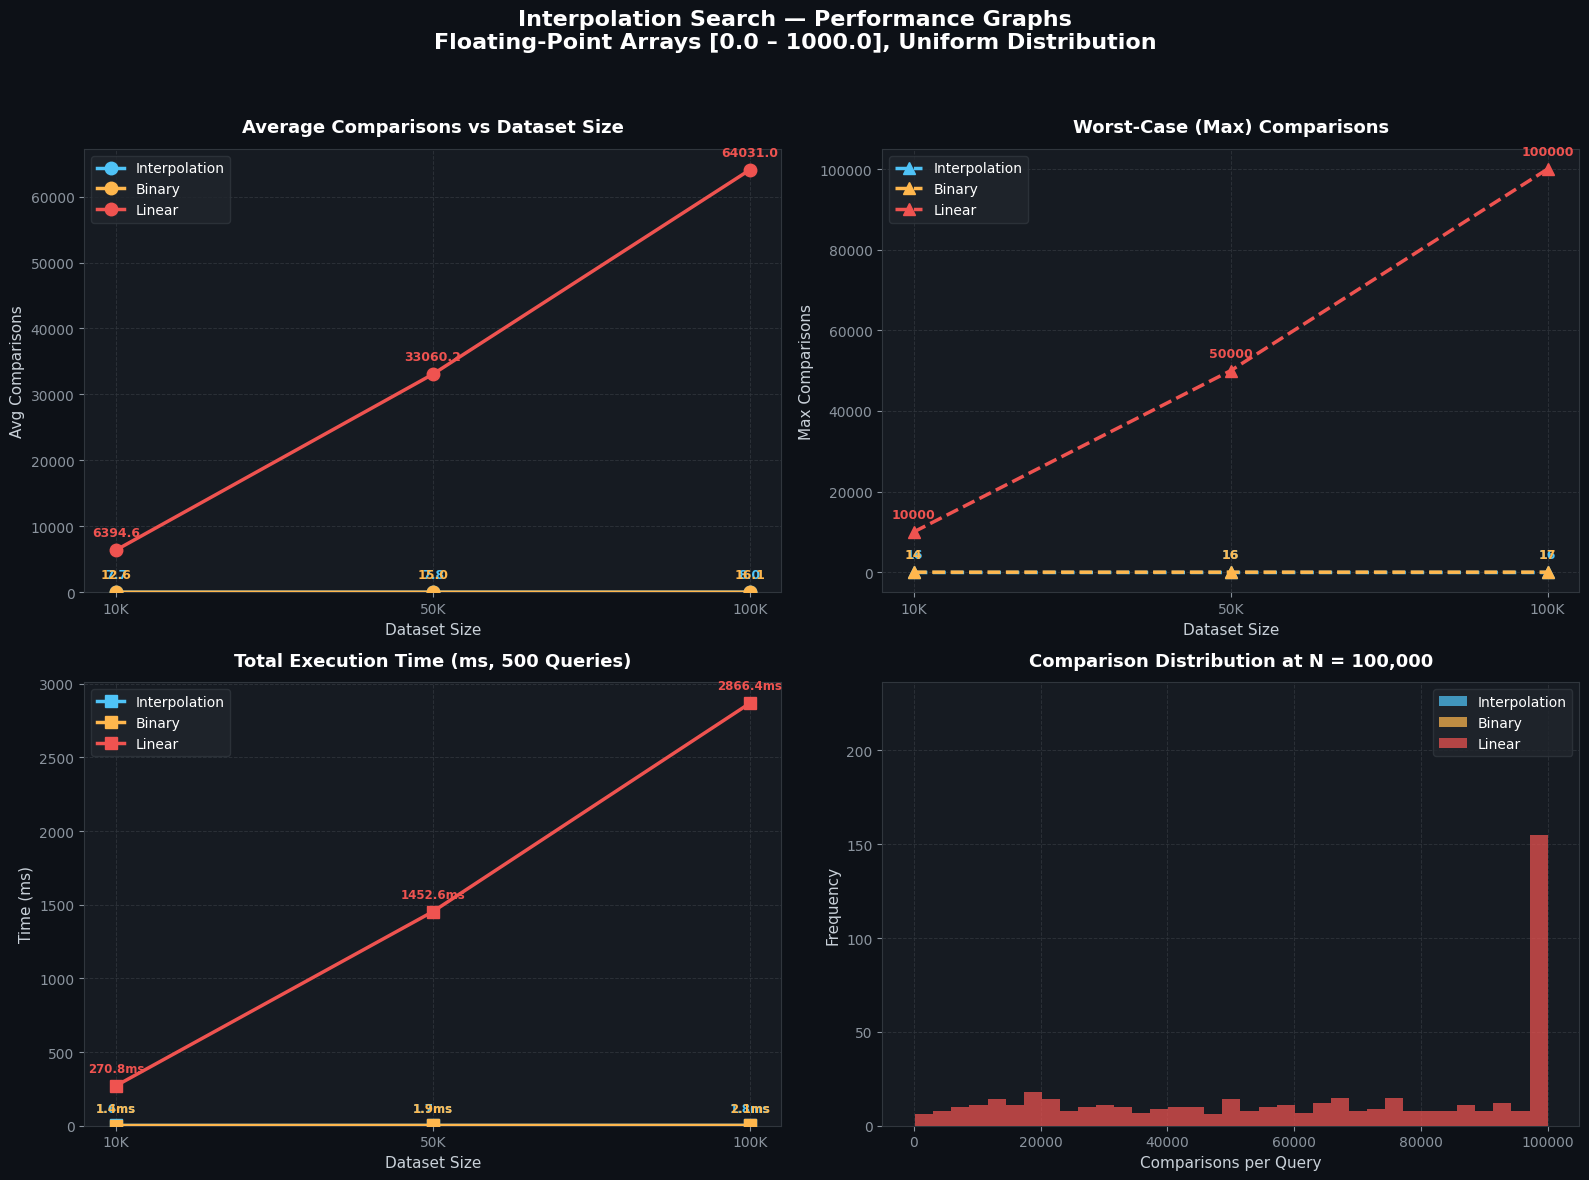

✅  Saved → performance_graphs.png


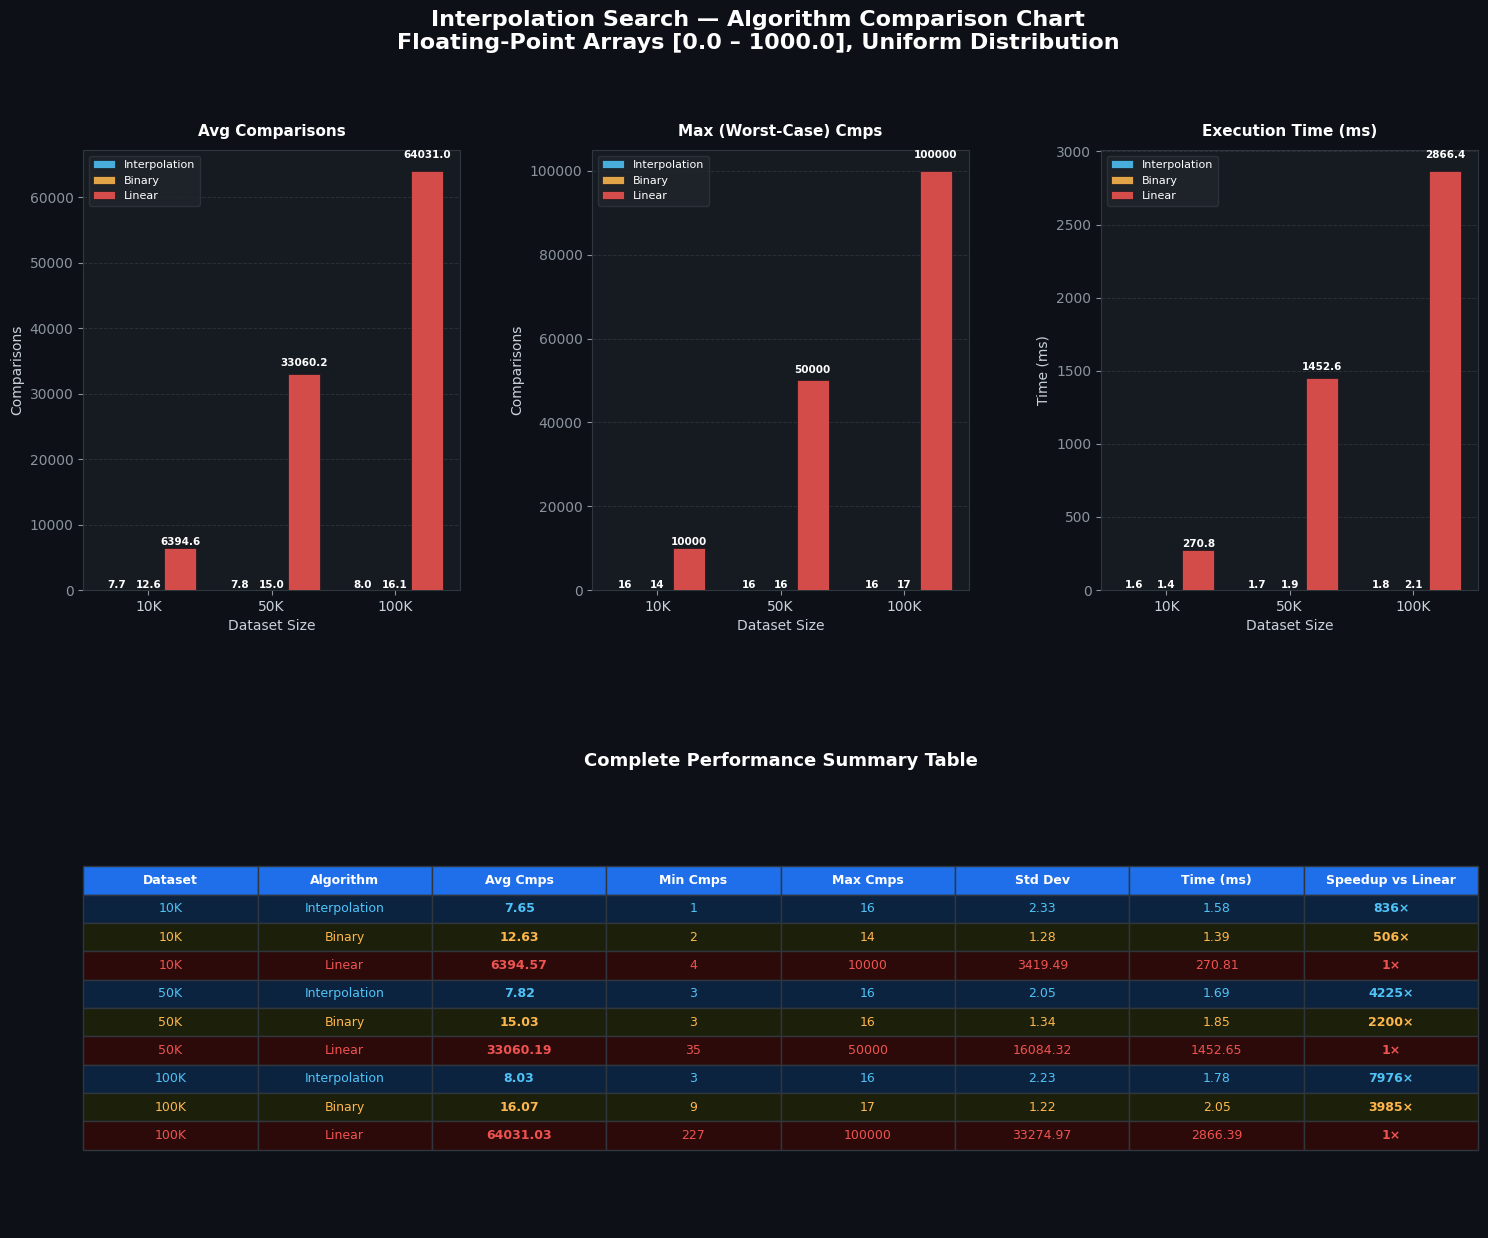

✅  Saved → comparison_chart.png

┌──────────────────────────────────────────────────────────────┐
│              THEORETICAL COMPLEXITY SUMMARY                  │
├─────────────────────┬───────────────┬──────────────────────┐
│  Algorithm          │  Average Case │  Worst Case          │
├─────────────────────┼───────────────┼──────────────────────┤
│  Interpolation      │  O(log log n) │  O(n) skewed dist.   │
│  Binary Search      │  O(log n)     │  O(log n)            │
│  Linear Search      │  O(n)         │  O(n)                │
└─────────────────────┴───────────────┴──────────────────────┘

KEY INSIGHT:
  • For UNIFORM distributions, Interpolation Search achieves
    O(log log n) — dramatically fewer comparisons than Binary.
  • At N=100,000:
      log₂(100000)        ≈ 17  comparisons  (Binary)
      log₂(log₂(100000)) ≈  4  comparisons  (Interpolation)
  • Probe formula exploits value distribution:
      pos = lo + (target − arr[lo])
                ─────────────────── × (hi −

In [4]:
# ================================================================
#  Interpolation Search on Floating-Point Numbers
#  Generates TWO image files:
#    1. performance_graphs.png   — 4-panel line/histogram charts
#    2. comparison_chart.png     — grouped bars + full summary table
#
#  Run in Google Colab:
#    Just paste this entire file into a cell and run it.
#    No !pip install needed — only numpy & matplotlib (pre-installed).
# ================================================================

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
import time
import random
from collections import defaultdict

# ────────────────────────────────────────────────────────────────
# SECTION 1: SEARCH ALGORITHMS
# ────────────────────────────────────────────────────────────────

def interpolation_search(arr, target, tolerance=1e-9):
    """
    Interpolation Search for sorted float arrays.
    Probe formula:  pos = lo + (target - arr[lo]) / (arr[hi] - arr[lo]) * (hi - lo)
    Returns (index, comparisons).  index = -1 if not found.
    """
    lo, hi = 0, len(arr) - 1
    comparisons = 0

    while lo <= hi and arr[lo] <= target <= arr[hi]:
        comparisons += 1                          # boundary check

        if arr[hi] == arr[lo]:                    # all equal in range
            comparisons += 1
            if abs(arr[lo] - target) <= tolerance:
                return lo, comparisons
            return -1, comparisons

        # Linear interpolation probe
        pos = lo + int((target - arr[lo]) / (arr[hi] - arr[lo]) * (hi - lo))
        pos = max(lo, min(pos, hi))               # clamp

        comparisons += 1
        if abs(arr[pos] - target) <= tolerance:
            return pos, comparisons
        elif arr[pos] < target:
            lo = pos + 1
        else:
            hi = pos - 1

    comparisons += 1                              # final miss check
    return -1, comparisons


def binary_search(arr, target, tolerance=1e-9):
    """Standard Binary Search — O(log n) baseline."""
    lo, hi = 0, len(arr) - 1
    comparisons = 0
    while lo <= hi:
        mid = (lo + hi) // 2
        comparisons += 1
        if abs(arr[mid] - target) <= tolerance:
            return mid, comparisons
        elif arr[mid] < target:
            lo = mid + 1
        else:
            hi = mid - 1
    return -1, comparisons


def linear_search(arr, target, tolerance=1e-9):
    """Linear Search — O(n) baseline."""
    for i, val in enumerate(arr):
        if abs(val - target) <= tolerance:
            return i, i + 1
    return -1, len(arr)


# ────────────────────────────────────────────────────────────────
# SECTION 2: EXPERIMENT — collect comparison counts & timings
# ────────────────────────────────────────────────────────────────

DATASET_SIZES = [10_000, 50_000, 100_000]
NUM_QUERIES   = 500          # queries per size (70 % hits, 30 % misses)
SEED          = 42
LOW,  HIGH    = 0.0, 1000.0

ALGOS  = ["Interpolation", "Binary", "Linear"]
COLORS = {
    "Interpolation": "#4FC3F7",   # sky blue
    "Binary":        "#FFB74D",   # amber
    "Linear":        "#EF5350",   # coral red
}

rng = np.random.default_rng(SEED)
results = {}   # results[size][algo] = list of comparison counts
timing  = {}   # timing[size][algo]  = total seconds for NUM_QUERIES

print("=" * 62)
print("  RUNNING EXPERIMENTS …")
print("=" * 62)

for size in DATASET_SIZES:
    # Sorted uniform float array
    data = np.sort(rng.uniform(LOW, HIGH, size)).tolist()

    # Query set: 70 % elements that exist, 30 % random (likely misses)
    n_hits   = int(NUM_QUERIES * 0.7)
    n_misses = NUM_QUERIES - n_hits
    hit_targets  = [data[rng.integers(0, size)] for _ in range(n_hits)]
    miss_targets = rng.uniform(LOW, HIGH, n_misses).tolist()
    targets = hit_targets + miss_targets
    random.shuffle(targets)

    algo_results = defaultdict(list)
    algo_timing  = {}

    for name, fn in [
        ("Interpolation", interpolation_search),
        ("Binary",        binary_search),
        ("Linear",        linear_search),
    ]:
        t0 = time.perf_counter()
        for tgt in targets:
            _, cmps = fn(data, tgt)
            algo_results[name].append(cmps)
        algo_timing[name] = time.perf_counter() - t0

    results[size] = dict(algo_results)
    timing[size]  = algo_timing

    # Console summary
    print(f"\n  Dataset: {size:,}")
    print(f"  {'Algorithm':<18} {'Avg':>8} {'Max':>8} {'Min':>8} {'ms':>10}")
    print("  " + "─" * 50)
    for a in ALGOS:
        cmps = results[size][a]
        ms   = timing[size][a] * 1000
        print(f"  {a:<18} {np.mean(cmps):>8.2f} {np.max(cmps):>8} {np.min(cmps):>8} {ms:>10.2f}")

print("\n" + "=" * 62)

# Pre-compute aggregates
x_labels   = ["10K", "50K", "100K"]
avg_cmps   = {a: [np.mean(results[s][a]) for s in DATASET_SIZES] for a in ALGOS}
max_cmps   = {a: [np.max (results[s][a]) for s in DATASET_SIZES] for a in ALGOS}
min_cmps   = {a: [np.min (results[s][a]) for s in DATASET_SIZES] for a in ALGOS}
total_time = {a: [timing [s][a] * 1000  for s in DATASET_SIZES] for a in ALGOS}

# Shared style helpers
BG_DARK  = "#0D1117"
BG_PANEL = "#161B22"
GRID_KW  = dict(color="#30363D", linestyle="--", linewidth=0.7, alpha=0.8)


def style_ax(ax):
    ax.set_facecolor(BG_PANEL)
    for spine in ax.spines.values():
        spine.set_color("#30363D")
    ax.tick_params(colors="#8B949E", labelsize=10)
    ax.xaxis.label.set_color("#C9D1D9")
    ax.yaxis.label.set_color("#C9D1D9")


# ────────────────────────────────────────────────────────────────
# SECTION 3: FIGURE 1 — Performance Graphs (4 panels)
# ────────────────────────────────────────────────────────────────

fig1, axes = plt.subplots(2, 2, figsize=(16, 12))
fig1.patch.set_facecolor(BG_DARK)
fig1.suptitle(
    "Interpolation Search — Performance Graphs\n"
    "Floating-Point Arrays [0.0 – 1000.0], Uniform Distribution",
    color="white", fontsize=16, fontweight="bold", y=0.98
)

for ax in axes.flat:
    style_ax(ax)

# ── Panel A: Average comparisons (line) ──────────────────────
ax = axes[0, 0]
for algo in ALGOS:
    ax.plot(x_labels, avg_cmps[algo], marker="o", linewidth=2.5,
            label=algo, color=COLORS[algo], markersize=9, zorder=5)
    for xi, yi in zip(x_labels, avg_cmps[algo]):
        ax.annotate(f"{yi:.1f}", (xi, yi), textcoords="offset points",
                    xytext=(0, 10), ha="center", color=COLORS[algo],
                    fontsize=9, fontweight="bold")
ax.set_title("Average Comparisons vs Dataset Size",
             color="white", fontsize=13, fontweight="bold", pad=12)
ax.set_xlabel("Dataset Size", fontsize=11)
ax.set_ylabel("Avg Comparisons", fontsize=11)
ax.legend(facecolor="#21262D", edgecolor="#30363D", labelcolor="white", fontsize=10)
ax.grid(**GRID_KW)
ax.set_ylim(bottom=0)

# ── Panel B: Worst-case comparisons (dashed line) ────────────
ax = axes[0, 1]
for algo in ALGOS:
    ax.plot(x_labels, max_cmps[algo], marker="^", linewidth=2.5,
            label=algo, color=COLORS[algo], markersize=9,
            linestyle="--", zorder=5)
    for xi, yi in zip(x_labels, max_cmps[algo]):
        ax.annotate(f"{int(yi)}", (xi, yi), textcoords="offset points",
                    xytext=(0, 10), ha="center", color=COLORS[algo],
                    fontsize=9, fontweight="bold")
ax.set_title("Worst-Case (Max) Comparisons",
             color="white", fontsize=13, fontweight="bold", pad=12)
ax.set_xlabel("Dataset Size", fontsize=11)
ax.set_ylabel("Max Comparisons", fontsize=11)
ax.legend(facecolor="#21262D", edgecolor="#30363D", labelcolor="white", fontsize=10)
ax.grid(**GRID_KW)

# ── Panel C: Execution time (line) ───────────────────────────
ax = axes[1, 0]
for algo in ALGOS:
    ax.plot(x_labels, total_time[algo], marker="s", linewidth=2.5,
            label=algo, color=COLORS[algo], markersize=9, zorder=5)
    for xi, yi in zip(x_labels, total_time[algo]):
        ax.annotate(f"{yi:.1f}ms", (xi, yi), textcoords="offset points",
                    xytext=(0, 10), ha="center", color=COLORS[algo],
                    fontsize=8.5, fontweight="bold")
ax.set_title("Total Execution Time (ms, 500 Queries)",
             color="white", fontsize=13, fontweight="bold", pad=12)
ax.set_xlabel("Dataset Size", fontsize=11)
ax.set_ylabel("Time (ms)", fontsize=11)
ax.legend(facecolor="#21262D", edgecolor="#30363D", labelcolor="white", fontsize=10)
ax.grid(**GRID_KW)
ax.set_ylim(bottom=0)

# ── Panel D: Comparison count histogram at N=100K ────────────
ax = axes[1, 1]
for algo in ALGOS:
    ax.hist(results[100_000][algo], bins=35, alpha=0.72,
            label=algo, color=COLORS[algo], edgecolor="none", zorder=4)
ax.set_title("Comparison Distribution at N = 100,000",
             color="white", fontsize=13, fontweight="bold", pad=12)
ax.set_xlabel("Comparisons per Query", fontsize=11)
ax.set_ylabel("Frequency", fontsize=11)
ax.legend(facecolor="#21262D", edgecolor="#30363D", labelcolor="white", fontsize=10)
ax.grid(**GRID_KW)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.savefig("performance_graphs.png", dpi=160,
            bbox_inches="tight", facecolor=fig1.get_facecolor())
plt.show()
print("✅  Saved → performance_graphs.png")


# ────────────────────────────────────────────────────────────────
# SECTION 4: FIGURE 2 — Comparison Chart (bars + table)
# ────────────────────────────────────────────────────────────────

fig2 = plt.figure(figsize=(18, 14))
fig2.patch.set_facecolor(BG_DARK)
fig2.suptitle(
    "Interpolation Search — Algorithm Comparison Chart\n"
    "Floating-Point Arrays [0.0 – 1000.0], Uniform Distribution",
    color="white", fontsize=16, fontweight="bold", y=0.98
)

gs = GridSpec(2, 3, figure=fig2, hspace=0.45, wspace=0.35)
ax1 = fig2.add_subplot(gs[0, 0])
ax2 = fig2.add_subplot(gs[0, 1])
ax3 = fig2.add_subplot(gs[0, 2])
ax4 = fig2.add_subplot(gs[1, :])

for ax in [ax1, ax2, ax3, ax4]:
    style_ax(ax)

x_pos = np.arange(len(DATASET_SIZES))
BAR_W = 0.26


def draw_grouped_bar(ax, data_dict, title, ylabel, fmt="{:.1f}"):
    """Draw a grouped bar chart for the three algorithms."""
    for i, algo in enumerate(ALGOS):
        vals = data_dict[algo]
        bars = ax.bar(x_pos + i * BAR_W, vals, BAR_W, label=algo,
                      color=COLORS[algo], alpha=0.88, zorder=3,
                      edgecolor=BG_DARK, linewidth=0.5)
        for bar, v in zip(bars, vals):
            h = bar.get_height()
            ax.text(bar.get_x() + BAR_W / 2, h + h * 0.025,
                    fmt.format(v), ha="center", va="bottom",
                    color="white", fontsize=7.5, fontweight="bold")
    ax.set_xticks(x_pos + BAR_W)
    ax.set_xticklabels(x_labels, color="#C9D1D9")
    ax.set_title(title, color="white", fontsize=11, fontweight="bold", pad=10)
    ax.set_xlabel("Dataset Size", fontsize=10)
    ax.set_ylabel(ylabel, fontsize=10)
    ax.legend(facecolor="#21262D", edgecolor="#30363D",
              labelcolor="white", fontsize=8)
    ax.grid(axis="y", **GRID_KW)
    ax.set_ylim(bottom=0)


draw_grouped_bar(ax1, avg_cmps,   "Avg Comparisons",       "Comparisons", "{:.1f}")
draw_grouped_bar(ax2, max_cmps,   "Max (Worst-Case) Cmps", "Comparisons", "{:.0f}")
draw_grouped_bar(ax3, total_time, "Execution Time (ms)",    "Time (ms)",   "{:.1f}")

# ── Summary table ─────────────────────────────────────────────
ax4.axis("off")
col_labels = [
    "Dataset", "Algorithm", "Avg Cmps", "Min Cmps",
    "Max Cmps", "Std Dev", "Time (ms)", "Speedup vs Linear"
]
table_data = []
for size in DATASET_SIZES:
    lin_avg = np.mean(results[size]["Linear"])
    for algo in ALGOS:
        cmps  = results[size][algo]
        t_ms  = timing[size][algo] * 1000
        speed = lin_avg / np.mean(cmps)
        table_data.append([
            f"{size // 1000}K",
            algo,
            f"{np.mean(cmps):.2f}",
            f"{np.min(cmps)}",
            f"{np.max(cmps)}",
            f"{np.std(cmps):.2f}",
            f"{t_ms:.2f}",
            f"{speed:.0f}×",
        ])

tbl = ax4.table(cellText=table_data, colLabels=col_labels,
                cellLoc="center", loc="center")
tbl.auto_set_font_size(False)
tbl.set_fontsize(9)
tbl.scale(1, 1.7)

ROW_COLORS = {
    "Interpolation": ("#0C2340", "#4FC3F7"),
    "Binary":        ("#1C1F0A", "#FFB74D"),
    "Linear":        ("#2C0A0A", "#EF5350"),
}

for (row, col), cell in tbl.get_celld().items():
    cell.set_edgecolor("#30363D")
    if row == 0:
        cell.set_facecolor("#1F6FEB")
        cell.set_text_props(color="white", fontweight="bold")
        continue
    algo = table_data[row - 1][1]
    bg_c, fg_c = ROW_COLORS[algo]
    cell.set_facecolor(bg_c)
    cell.set_text_props(color=fg_c)
    if col in (2, 7):                             # bold Avg & Speedup
        cell.set_text_props(fontweight="bold")

ax4.set_title("Complete Performance Summary Table",
              color="white", fontsize=13, fontweight="bold", pad=16)

plt.savefig("comparison_chart.png", dpi=160,
            bbox_inches="tight", facecolor=fig2.get_facecolor())
plt.show()
print("✅  Saved → comparison_chart.png")


# ────────────────────────────────────────────────────────────────
# SECTION 5: COMPLEXITY SUMMARY
# ────────────────────────────────────────────────────────────────
print("""
┌──────────────────────────────────────────────────────────────┐
│              THEORETICAL COMPLEXITY SUMMARY                  │
├─────────────────────┬───────────────┬──────────────────────┐
│  Algorithm          │  Average Case │  Worst Case          │
├─────────────────────┼───────────────┼──────────────────────┤
│  Interpolation      │  O(log log n) │  O(n) skewed dist.   │
│  Binary Search      │  O(log n)     │  O(log n)            │
│  Linear Search      │  O(n)         │  O(n)                │
└─────────────────────┴───────────────┴──────────────────────┘

KEY INSIGHT:
  • For UNIFORM distributions, Interpolation Search achieves
    O(log log n) — dramatically fewer comparisons than Binary.
  • At N=100,000:
      log₂(100000)        ≈ 17  comparisons  (Binary)
      log₂(log₂(100000)) ≈  4  comparisons  (Interpolation)
  • Probe formula exploits value distribution:
      pos = lo + (target − arr[lo])
                ─────────────────── × (hi − lo)
                (arr[hi] − arr[lo])
""")
